# 우리말샘 미검색 법률용어 EDA

판례 필드에서 수집했지만 우리말샘 표제어 정확 일치 검색으로 정의를 찾지 못한 용어를 확인하는 노트북입니다.

- 입력: `local_data/precedents/legal_terms/urimalsaem_definitions/urimalsaem_not_found_terms.jsonl`
- 주요 데이터프레임: `unmatched_df`
- 확인 항목: 전체 미검색 건수, 판례 등장 빈도, 필드별 등장 현황, 특정 용어 검색
- 이 노트북은 원본 데이터를 수정하지 않습니다.

In [2]:
# 필요한 라이브러리를 불러옵니다.
from __future__ import annotations

import json
import os
import platform
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib_cache"))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_colwidth", 120)

In [3]:
# 프로젝트 루트와 데이터 경로를 설정합니다.
def find_project_root() -> Path:
    """현재 위치 주변에서 AlphaLawVA 데이터 폴더를 가진 프로젝트 루트를 찾습니다."""
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "local_data" / "precedents" / "legal_terms").exists():
            return candidate
    raise FileNotFoundError("프로젝트 루트를 찾지 못했습니다. AlphaLawVA 폴더 안에서 노트북을 실행해 주세요.")

PROJECT_ROOT = find_project_root()
DATA_PATH = (
    PROJECT_ROOT
    / "local_data"
    / "precedents"
    / "legal_terms"
    / "urimalsaem_definitions"
    / "urimalsaem_not_found_terms.jsonl"
)
MANIFEST_PATH = DATA_PATH.parent / "manifest.json"

print(f"프로젝트 루트: {PROJECT_ROOT}")
print(f"미검색 용어 파일: {DATA_PATH}")
assert DATA_PATH.exists(), f"파일이 없습니다: {DATA_PATH}"

프로젝트 루트: /Users/choeminju/Documents/AlphaLawVA
미검색 용어 파일: /Users/choeminju/Documents/AlphaLawVA/local_data/precedents/legal_terms/urimalsaem_definitions/urimalsaem_not_found_terms.jsonl


In [4]:
# JSONL을 읽고 필드별 등장 통계를 펼쳐 분석용 DataFrame으로 만듭니다.
def read_jsonl(path: Path) -> list[dict]:
    """빈 줄을 제외하고 JSONL 레코드를 읽습니다."""
    with path.open("r", encoding="utf-8") as file:
        return [json.loads(line) for line in file if line.strip()]

records = read_jsonl(DATA_PATH)
rows = []
for record in records:
    field_stats = record.get("field_stats", {})
    row = {
        "용어": record.get("term", ""),
        "매칭키": record.get("match_key", ""),
        "등장_판례수": record.get("total_case_count", 0),
        "총_등장횟수": record.get("total_occurrence_count", 0),
        "조회상태": record.get("lookup_status", ""),
        "선정상태": record.get("selection_status", ""),
    }
    for field_name in ["사건명", "생성요약", "판시사항", "판결요지", "주문", "청구취지"]:
        stats = field_stats.get(field_name, {})
        row[f"{field_name}_판례수"] = stats.get("case_count", 0)
        row[f"{field_name}_등장횟수"] = stats.get("occurrence_count", 0)
    rows.append(row)

unmatched_df = (
    pd.DataFrame(rows)
    .sort_values(["등장_판례수", "총_등장횟수", "용어"], ascending=[False, False, True])
    .reset_index(drop=True)
)
unmatched_df.index = unmatched_df.index + 1
unmatched_df.index.name = "순번"

print(f"우리말샘 미검색 용어: {len(unmatched_df):,}개")

우리말샘 미검색 용어: 447개


In [5]:
# 수집 매니페스트와 기본 통계를 확인합니다.
if MANIFEST_PATH.exists():
    manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
    collection_summary = pd.DataFrame(
        [
            {
                "전체 조회 용어": manifest.get("candidate_count", 0),
                "정확 일치": manifest.get("lookup_status_counts", {}).get("exact", 0),
                "미검색": manifest.get("lookup_status_counts", {}).get("not_found", 0),
                "오류": manifest.get("error_count", 0),
                "수집 상태": manifest.get("status", ""),
                "수집 기준": manifest.get("search_method", ""),
            }
        ]
    )
    display(collection_summary)

display(
    unmatched_df[["등장_판례수", "총_등장횟수"]]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    .round(1)
)

,전체 조회 용어,정확 일치,미검색,오류,수집 상태,수집 기준
0,2670,2223,447,0,completed,표제어 정확 일치


,등장_판례수,총_등장횟수
count,447.0,447.0
mean,12.3,23.8
std,59.0,103.9
min,1.0,1.0
25%,1.0,1.0
50%,2.0,4.0
75%,6.0,12.0
90%,17.4,33.4
95%,32.0,74.1
99%,163.5,435.3


## 전체 미검색 용어 표

아래 `DISPLAY_ROWS` 값을 바꾸면 한 번에 표시할 행 수를 조절할 수 있습니다. `unmatched_df`에는 427개 전체 행이 들어 있습니다.

In [6]:
# 판례 등장 빈도가 높은 순서로 미검색 용어를 확인합니다.
DISPLAY_ROWS = 100
display(unmatched_df.head(DISPLAY_ROWS))

,용어,매칭키,등장_판례수,총_등장횟수,조회상태,선정상태,사건명_판례수,사건명_등장횟수,생성요약_판례수,생성요약_등장횟수,판시사항_판례수,판시사항_등장횟수,판결요지_판례수,판결요지_등장횟수,주문_판례수,주문_등장횟수,청구취지_판례수,청구취지_등장횟수
순번,,,,,,,,,,,,,,,,,,
1,원심판결,원심판결,957,1408,not_found,unresolved,0,0,223,224,114,115,109,114,917,937,15,18
2,제1심,제1심,573,1268,not_found,unresolved,0,0,41,53,26,30,34,67,380,440,410,678
3,특별한 사정,특별한사정,393,566,not_found,unresolved,0,0,145,148,30,32,326,386,0,0,0,0
4,부동산 매매,부동산매매,241,384,not_found,unresolved,1,1,216,221,71,73,80,88,1,1,0,0
5,근저당권설정,근저당권설정,181,487,not_found,unresolved,46,46,51,65,60,74,81,146,27,32,49,124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,경매개시,경매개시,8,8,not_found,unresolved,1,1,3,3,1,1,3,3,0,0,0,0
97,전대인,전대인,7,35,not_found,unresolved,0,0,6,11,5,8,4,16,0,0,0,0
98,가압류채권자,가압류채권자,7,30,not_found,unresolved,0,0,3,5,6,11,6,14,0,0,0,0


,필드,용어별_판례수_합계,용어별_등장횟수_합계,등장한_미검색용어수
0,판결요지,2563,3862,367
1,생성요약,1748,2036,216
2,판시사항,1491,1851,249
3,주문,1427,1528,48
4,청구취지,690,1160,54
5,사건명,182,185,33


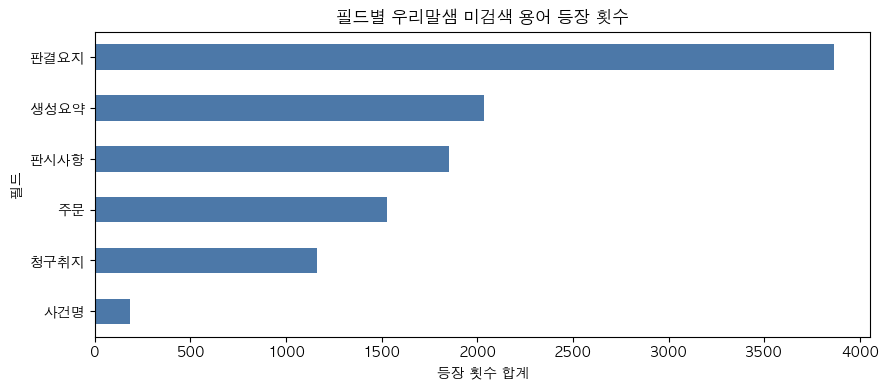

In [7]:
# 미검색 용어가 어느 판례 필드에서 자주 등장했는지 집계합니다.
field_names = ["사건명", "생성요약", "판시사항", "판결요지", "주문", "청구취지"]
field_summary = pd.DataFrame(
    {
        "필드": field_names,
        "용어별_판례수_합계": [int(unmatched_df[f"{name}_판례수"].sum()) for name in field_names],
        "용어별_등장횟수_합계": [int(unmatched_df[f"{name}_등장횟수"].sum()) for name in field_names],
        "등장한_미검색용어수": [int((unmatched_df[f"{name}_등장횟수"] > 0).sum()) for name in field_names],
    }
).sort_values("용어별_등장횟수_합계", ascending=False)

display(field_summary.reset_index(drop=True))

ax = field_summary.set_index("필드")["용어별_등장횟수_합계"].sort_values().plot(
    kind="barh", figsize=(9, 4), color="#4C78A8"
)
ax.set_title("필드별 우리말샘 미검색 용어 등장 횟수")
ax.set_xlabel("등장 횟수 합계")
ax.set_ylabel("필드")
plt.tight_layout()
plt.show()

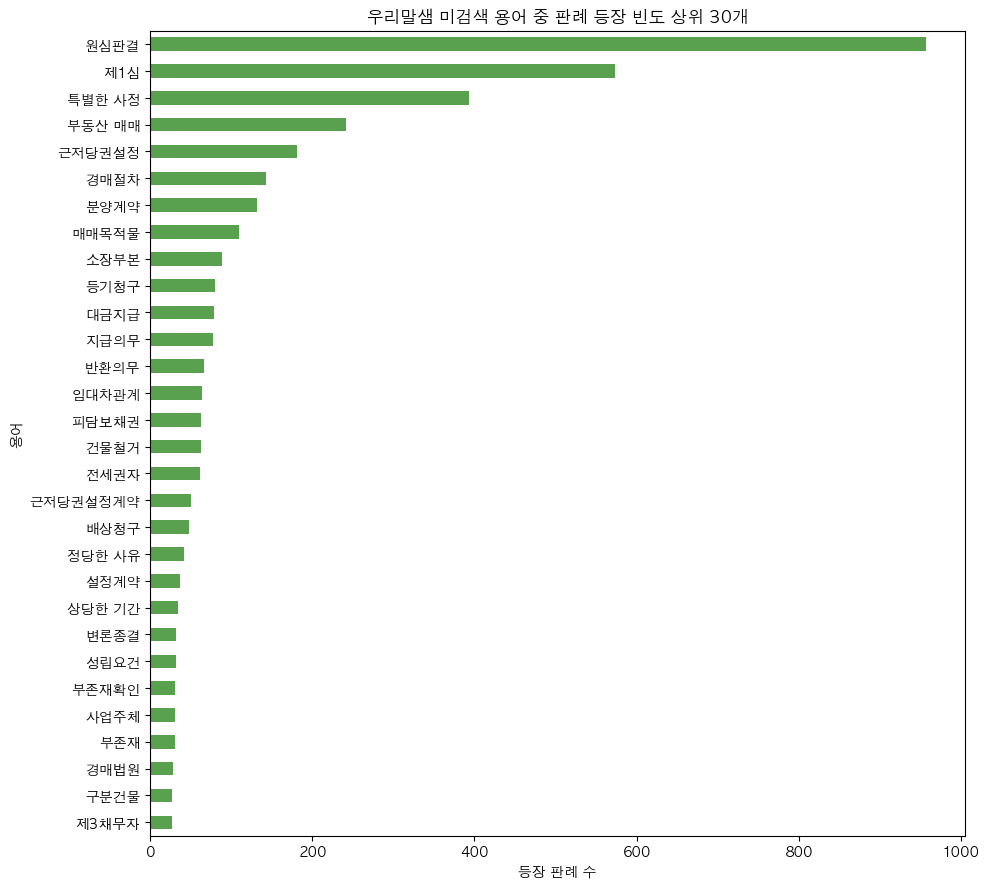

In [8]:
# 판례 등장 빈도가 높은 미검색 용어를 그래프로 확인합니다.
TOP_N = 30
top_terms = unmatched_df.head(TOP_N).sort_values("등장_판례수")

ax = top_terms.plot(
    x="용어",
    y="등장_판례수",
    kind="barh",
    figsize=(10, 9),
    color="#59A14F",
    legend=False,
)
ax.set_title(f"우리말샘 미검색 용어 중 판례 등장 빈도 상위 {TOP_N}개")
ax.set_xlabel("등장 판례 수")
ax.set_ylabel("용어")
plt.tight_layout()
plt.show()

## 원하는 조건으로 필터링

`SEARCH_TERM`에 일부 문자열을 입력하거나 `MIN_CASE_COUNT`를 조절해 확인할 수 있습니다. 빈 문자열이면 모든 용어를 대상으로 합니다.

In [9]:
# 검색어와 최소 판례 수를 지정해 필요한 용어만 확인합니다.
SEARCH_TERM = ""  # 예: 원심, 등기, 임대차
MIN_CASE_COUNT = 1

filtered_df = unmatched_df[
    unmatched_df["용어"].str.contains(SEARCH_TERM, case=False, na=False)
    & (unmatched_df["등장_판례수"] >= MIN_CASE_COUNT)
].copy()

print(f"조건에 맞는 용어: {len(filtered_df):,}개")
display(filtered_df)

조건에 맞는 용어: 447개


,용어,매칭키,등장_판례수,총_등장횟수,조회상태,선정상태,사건명_판례수,사건명_등장횟수,생성요약_판례수,생성요약_등장횟수,판시사항_판례수,판시사항_등장횟수,판결요지_판례수,판결요지_등장횟수,주문_판례수,주문_등장횟수,청구취지_판례수,청구취지_등장횟수
순번,,,,,,,,,,,,,,,,,,
1,원심판결,원심판결,957,1408,not_found,unresolved,0,0,223,224,114,115,109,114,917,937,15,18
2,제1심,제1심,573,1268,not_found,unresolved,0,0,41,53,26,30,34,67,380,440,410,678
3,특별한 사정,특별한사정,393,566,not_found,unresolved,0,0,145,148,30,32,326,386,0,0,0,0
4,부동산 매매,부동산매매,241,384,not_found,unresolved,1,1,216,221,71,73,80,88,1,1,0,0
5,근저당권설정,근저당권설정,181,487,not_found,unresolved,46,46,51,65,60,74,81,146,27,32,49,124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443,택지개발사업,택지개발사업,1,1,not_found,unresolved,0,0,1,1,0,0,0,0,0,0,0,0
444,판단능력,판단능력,1,1,not_found,unresolved,0,0,0,0,0,0,1,1,0,0,0,0
445,평가방법,평가방법,1,1,not_found,unresolved,0,0,0,0,0,0,1,1,0,0,0,0
